# Time Series Analysis for Cluster 2

This notebook performs time series analysis on hourly demand data for cluster 2.

In [22]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [24]:
# Load the hourly demand data
df = pd.read_csv('data/hourly_demand_2018_2019_complete.csv')
print(f"Data shape: {df.shape}")
df.head()

Data shape: (526110, 6)


,cluster,hour,pickups,dropoffs,year,total_demand
0,0.0,2018-01-01 00:00:00,3,2,2018,5
1,0.0,2018-01-01 01:00:00,1,5,2018,6
2,0.0,2018-01-01 02:00:00,4,1,2018,5
3,0.0,2018-01-01 03:00:00,0,1,2018,1
4,0.0,2018-01-01 04:00:00,0,0,2018,0


In [35]:
# Check columns and filter for 2018 data only
print("Columns in dataframe:", df.columns.tolist())

# Find the datetime column (could be 'datetime', 'date', 'timestamp', etc.)
datetime_col = 'hour'

df[datetime_col] = pd.to_datetime(df[datetime_col])
df_2018 = df[df[datetime_col].dt.year == 2018].copy()


print(f"2018 data shape: {df_2018.shape}")
df_2018.head()

Columns in dataframe: ['cluster', 'hour', 'pickups', 'dropoffs', 'year', 'total_demand']
2018 data shape: (262800, 6)


,cluster,hour,pickups,dropoffs,year,total_demand
0,0.0,2018-01-01 00:00:00,3,2,2018,5
1,0.0,2018-01-01 01:00:00,1,5,2018,6
2,0.0,2018-01-01 02:00:00,4,1,2018,5
3,0.0,2018-01-01 03:00:00,0,1,2018,1
4,0.0,2018-01-01 04:00:00,0,0,2018,0


In [36]:
# Filter for cluster 2 only
cluster_2_data = df_2018[df_2018['cluster'] == 2].copy()
print(f"Cluster 2 data shape: {cluster_2_data.shape}")
cluster_2_data.head()

Cluster 2 data shape: (8760, 6)


,cluster,hour,pickups,dropoffs,year,total_demand
35074,2.0,2018-01-01 00:00:00,15,4,2018,19
35075,2.0,2018-01-01 01:00:00,20,17,2018,37
35076,2.0,2018-01-01 02:00:00,8,8,2018,16
35077,2.0,2018-01-01 03:00:00,5,7,2018,12
35078,2.0,2018-01-01 04:00:00,4,0,2018,4


In [37]:
# Prepare time series data
# Assuming there's a datetime column - we'll need to set it as index
# Let's first check the columns
cluster_2_data.columns

Index(['cluster', 'hour', 'pickups', 'dropoffs', 'year', 'total_demand'], dtype='object')

In [ ]:
# Set datetime as index and prepare time series
# Adjust the column name based on what's in the data
# if 'datetime' in cluster_2_data.columns:
#     cluster_2_data['datetime'] = pd.to_datetime(cluster_2_data['datetime'])
#     cluster_2_data = cluster_2_data.set_index('datetime')
# elif 'date' in cluster_2_data.columns:
#     cluster_2_data['date'] = pd.to_datetime(cluster_2_data['date'])
#     cluster_2_data = cluster_2_data.set_index('date')
cluster_2_data['hour'] = pd.to_datetime(cluster_2_data['hour'])
cluster_2_data = cluster_2_data.set_index('hour')
# Sort by index
cluster_2_data = cluster_2_data.sort_index()

# Get the pickups column (assuming it's named 'pickups')
ts_data = cluster_2_data['pickups']


print(f"Time series data shape: {ts_data.shape}")
ts_data.head()

Time series data shape: (8760,)


hour
2018-01-01 00:00:00    15
2018-01-01 01:00:00    20
2018-01-01 02:00:00     8
2018-01-01 03:00:00     5
2018-01-01 04:00:00     4
Name: pickups, dtype: int64

## Seasonal Decomposition

Using `seasonal_decompose` to break down the time series into trend, seasonal, and residual components.

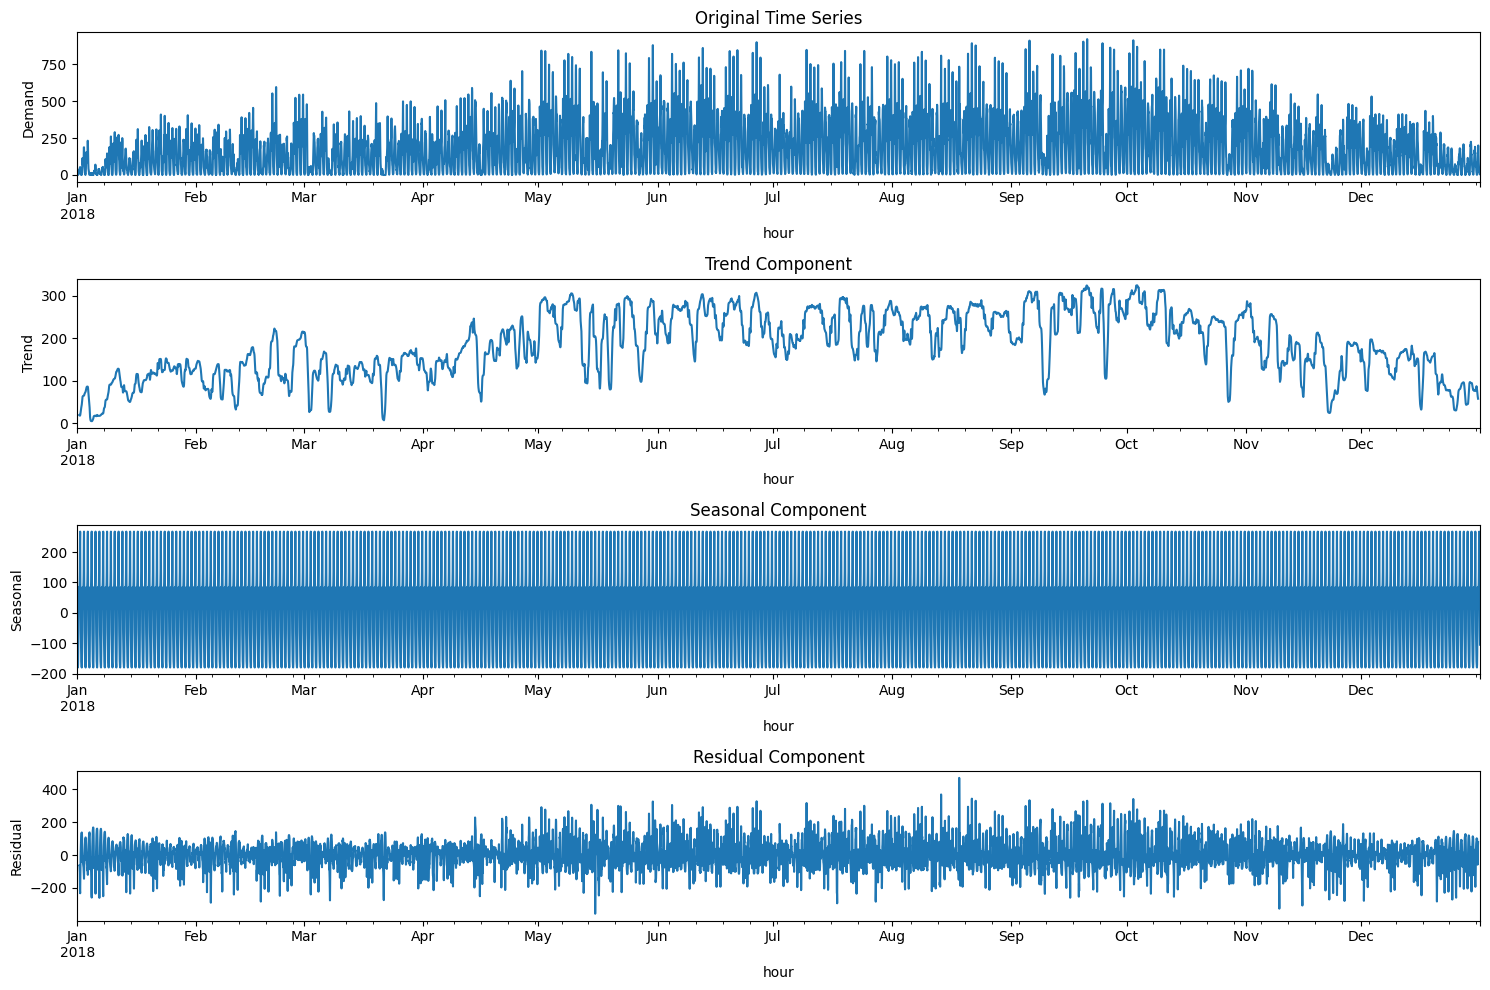

In [ ]:
# Perform seasonal decomposition
# Using period=24 for hourly data (24 hours in a day)
# Adjust period if needed based on your data characteristics
decomposition = seasonal_decompose(ts_data, model='additive', period=24)

# Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(15, 10))

# Original
ts_data.plot(ax=axes[0], title='Original Time Series')
axes[0].set_ylabel('Pickups')

# Trend
decomposition.trend.plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')

# Seasonal
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component')
axes[2].set_ylabel('Seasonal')

# Residual
decomposition.resid.plot(ax=axes[3], title='Residual Component')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## ARIMA Model Training

Training a dummy ARIMA(0,0,0) model as a baseline.
- Training data: January to October 2018
- Validation data: November and December 2018

In [40]:
# Split data into train (Jan-Oct) and validation (Nov-Dec)
train_ts = ts_data[ts_data.index.month <= 10]
val_ts = ts_data[ts_data.index.month >= 11]

print(f"Training data shape: {train_ts.shape}")
print(f"Training period: {train_ts.index.min()} to {train_ts.index.max()}")
print(f"\nValidation data shape: {val_ts.shape}")
print(f"Validation period: {val_ts.index.min()} to {val_ts.index.max()}")

# Train dummy ARIMA(0,0,0) model on training data
arima = ARIMA(train_ts, order=(0,0,0), enforce_invertibility=False, enforce_stationarity=False)
results = arima.fit()

# Display summary
results.summary()

Training data shape: (7296,)
Training period: 2018-01-01 00:00:00 to 2018-10-31 23:00:00

Validation data shape: (1464,)
Validation period: 2018-11-01 00:00:00 to 2018-12-31 23:00:00


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                pickups   No. Observations:                 7296
Model:                          ARIMA   Log Likelihood              -48180.796
Date:                Wed, 03 Dec 2025   AIC                          96365.592
Time:                        23:32:55   BIC                          96379.382
Sample:                    01-01-2018   HQIC                         96370.334
                         - 10-31-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        194.4425      2.661     73.073      0.000     189.227     199.658
sigma2       3.19e+04    575.730     55.407      0.000    3.08e+04     3.3e+04
===================================================================================
Ljung-Box (L1) (Q):                5781.34   Jarque-Bera (JB):              1426.99
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.33   Skew:                             1.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

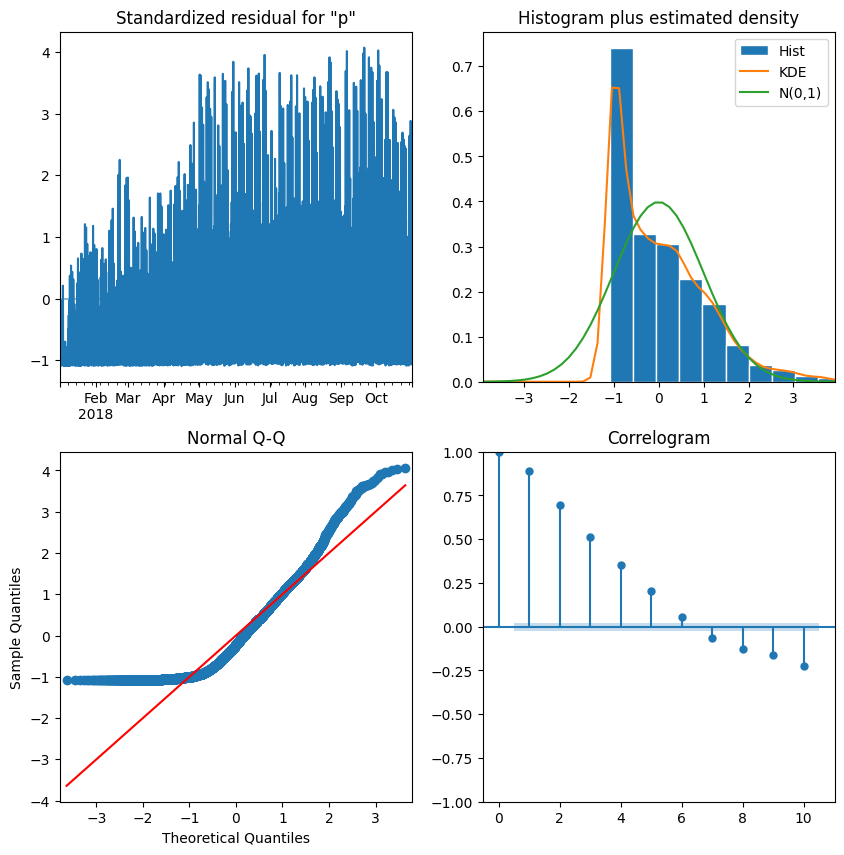

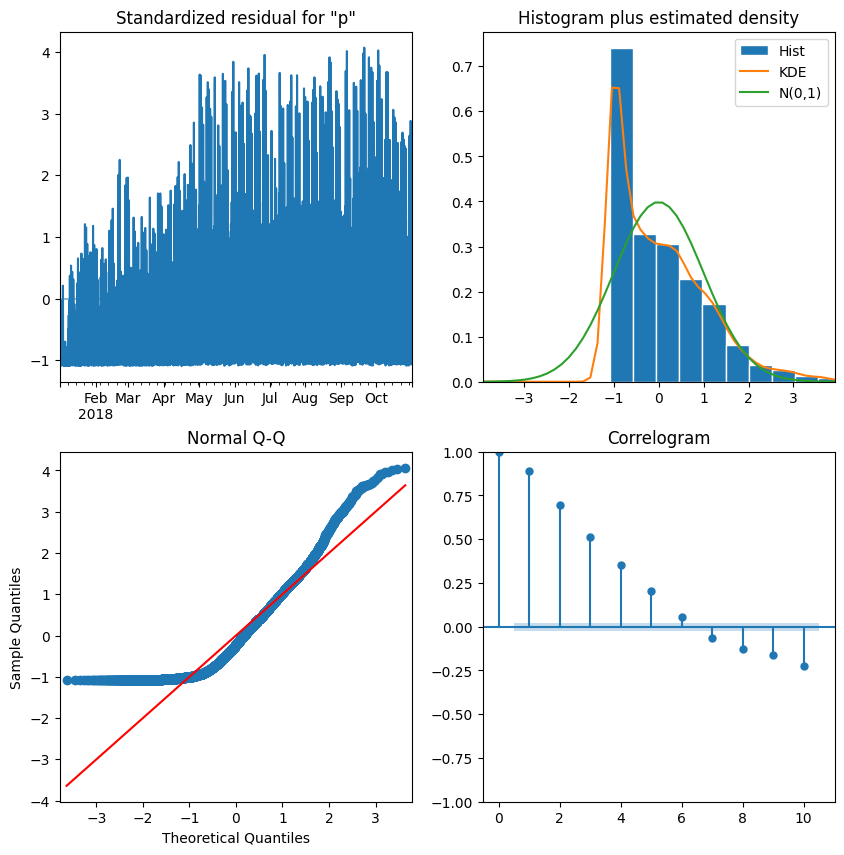

In [41]:
# # Display the model
# print("Model:", arima)
# print("\nFitted Results:", results)
results.plot_diagnostics(figsize = (10,10))

In [44]:
# Rolling forecast: Predict 24 hours at a time
# This simulates real-world scenario: at end of each day, predict next 24 hours

val_predictions = []
val_actual = []

# Iterate through validation period, predicting 24 hours at a time
for i in range(0, len(val_ts), 24):
    # Get the next 24 hours (or remaining hours if less than 24)
    end_idx = min(i + 24, len(val_ts))
    
    # Train on all data up to this point (Jan-Oct + previous validation days)
    if i == 0:
        # First prediction: use only training data
        train_data = train_ts
    else:
        # Subsequent predictions: include actual data from previous days
        train_data = pd.concat([train_ts, val_ts.iloc[:i]])
    
    # Fit ARIMA model
    model = ARIMA(train_data, order=(0,0,0), enforce_invertibility=False, enforce_stationarity=False)
    fitted = model.fit()
    
    # Forecast next 24 hours (or remaining hours)
    forecast_steps = end_idx - i
    forecast = fitted.forecast(steps=forecast_steps)
    
    # Store predictions and actual values
    val_predictions.extend(forecast.values)
    val_actual.extend(val_ts.iloc[i:end_idx].values)
    
    print(f"Day {i//24 + 1}: Predicted hours {i} to {end_idx} (forecast from {train_data.index[-1]})")

# Convert to arrays for plotting
val_predictions = np.array(val_predictions)
val_actual = np.array(val_actual)

print(f"\nTotal predictions made: {len(val_predictions)}")
print(f"Total actual values: {len(val_actual)}")

Day 1: Predicted hours 0 to 24 (forecast from 2018-10-31 23:00:00)
Day 2: Predicted hours 24 to 48 (forecast from 2018-11-01 23:00:00)
Day 2: Predicted hours 24 to 48 (forecast from 2018-11-01 23:00:00)
Day 3: Predicted hours 48 to 72 (forecast from 2018-11-02 23:00:00)
Day 3: Predicted hours 48 to 72 (forecast from 2018-11-02 23:00:00)
Day 4: Predicted hours 72 to 96 (forecast from 2018-11-03 23:00:00)
Day 4: Predicted hours 72 to 96 (forecast from 2018-11-03 23:00:00)
Day 5: Predicted hours 96 to 120 (forecast from 2018-11-04 23:00:00)
Day 5: Predicted hours 96 to 120 (forecast from 2018-11-04 23:00:00)
Day 6: Predicted hours 120 to 144 (forecast from 2018-11-05 23:00:00)
Day 6: Predicted hours 120 to 144 (forecast from 2018-11-05 23:00:00)
Day 7: Predicted hours 144 to 168 (forecast from 2018-11-06 23:00:00)
Day 7: Predicted hours 144 to 168 (forecast from 2018-11-06 23:00:00)
Day 8: Predicted hours 168 to 192 (forecast from 2018-11-07 23:00:00)
Day 8: Predicted hours 168 to 192 (fo

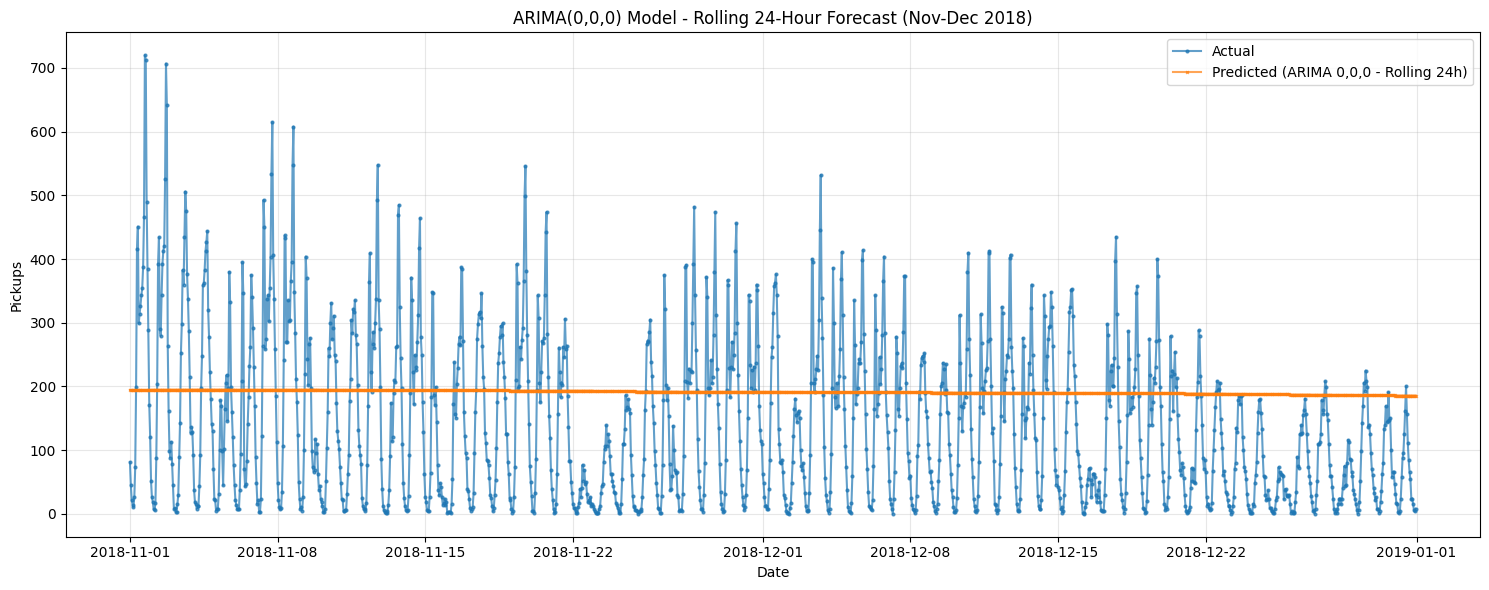


Validation Metrics (Rolling 24-Hour Forecast):
MSE: 18843.55
RMSE: 137.27
MAE: 117.57


In [46]:
# Plot actual vs predicted for validation period
plt.figure(figsize=(15, 6))
plt.plot(val_ts.index, val_actual, label='Actual', marker='o', markersize=2, alpha=0.7)
plt.plot(val_ts.index, val_predictions, label='Predicted (ARIMA 0,0,0 - Rolling 24h)', marker='x', markersize=2, alpha=0.7)
plt.title('ARIMA(0,0,0) Model - Rolling 24-Hour Forecast (Nov-Dec 2018)')
plt.xlabel('Date')
plt.ylabel('Pickups')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate validation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(val_actual, val_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(val_actual, val_predictions)

print(f"\nValidation Metrics (Rolling 24-Hour Forecast):")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")